# Customer Churn Prediction

## 1. Problem Statement

Customer churn occurs when a customer stops using a company’s service. This project predicts whether a telecom customer is likely to churn based on demographics, account details, subscribed services, and billing information.

## 2. Business Objective

The objective is to identify customers at risk of churn so that the telecom company can take proactive retention actions such as personalized offers, contract upgrades, and customer-support outreach.

## 3. Dataset Understanding

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

file_path = "../data/raw/Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

### Initial Dataset Observations

- The dataset contains 7,043 customer records and 21 columns.
- `Churn` is the target variable. It indicates whether a customer left the telecom service.
- `customerID` is a unique identifier and will be removed before model training.
- The dataset contains both categorical and numerical features.
- `TotalCharges` is expected to be numerical, but it is currently stored as an object data type and will be corrected during data cleaning.

In [5]:
print("Churn value counts:")
display(df["Churn"].value_counts())

print("\nChurn percentage:")
display((df["Churn"].value_counts(normalize=True) * 100).round(2))

Churn value counts:


Churn
No     5174
Yes    1869
Name: count, dtype: int64


Churn percentage:


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

In [6]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Target Variable Observation

- `Churn` is the target variable for this binary classification problem.
- `Yes` represents a customer who left the telecom service, while `No` represents a customer who stayed.
- The target classes are not equally distributed, so evaluation will include precision, recall, F1-score, and ROC-AUC in addition to accuracy.


## 4. Data Quality Checks and Cleaning

Before training models, we check whether the dataset has missing values, duplicate rows, incorrect data types, blank values, or unnecessary columns.

In [7]:
# Check missing values in every column
missing_values = df.isnull().sum()

print("Missing values per column:")
display(missing_values[missing_values > 0])

print("Total missing values:", missing_values.sum())

# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check number of unique values in each column
print("\nUnique values per column:")
display(df.nunique())

Missing values per column:


Series([], dtype: int64)

Total missing values: 0
Duplicate rows: 0

Unique values per column:


customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

### Data Quality Check Observation

- No standard null values were found in the dataset.
- Duplicate records were checked before preprocessing.
- Even when a dataset has no null values, text columns can contain blank strings. Therefore, `TotalCharges` will be checked separately because it should be numeric.

In [8]:
# Check blank or whitespace-only values in TotalCharges
blank_total_charges = df["TotalCharges"].astype(str).str.strip().eq("").sum()

print("Blank values in TotalCharges:", blank_total_charges)

# Show rows that contain blank TotalCharges values
display(df[df["TotalCharges"].astype(str).str.strip().eq("")])

Blank values in TotalCharges: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [9]:
# Convert blank spaces to missing values, then convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].astype(str).str.strip().replace("", np.nan),
    errors="coerce"
)

print("Data type after conversion:", df["TotalCharges"].dtype)
print("Missing values in TotalCharges after conversion:", df["TotalCharges"].isnull().sum())

display(df[df["TotalCharges"].isnull()])

Data type after conversion: float64
Missing values in TotalCharges after conversion: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [10]:
# Check the tenure values for rows with missing TotalCharges
display(df.loc[df["TotalCharges"].isnull(), ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [11]:
# New customers with tenure = 0 have not accumulated total charges yet.
# Therefore, fill missing TotalCharges values with 0.
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Missing values in TotalCharges after filling:", df["TotalCharges"].isnull().sum())
print("TotalCharges data type:", df["TotalCharges"].dtype)

Missing values in TotalCharges after filling: 0
TotalCharges data type: float64


### TotalCharges Cleaning Decision

- `TotalCharges` contained blank values that were converted to missing values.
- These records belonged to customers with `tenure = 0`, meaning they were new customers.
- Since new customers have not accumulated any charges yet, missing `TotalCharges` values were filled with `0`.
- The column was converted from `object` to `float64` so it can be used by machine-learning models.

In [12]:
# customerID is only a unique identifier.
# It does not describe customer behavior, so remove it before analysis and modeling.
df = df.drop(columns="customerID")

print("Dataset shape after removing customerID:", df.shape)
print("Is customerID still present?", "customerID" in df.columns)

Dataset shape after removing customerID: (7043, 20)
Is customerID still present? False


In [13]:
print("Final missing values:", df.isnull().sum().sum())
print("Final duplicate rows:", df.duplicated().sum())
print("Final dataset shape:", df.shape)

display(df.head())

Final missing values: 0
Final duplicate rows: 22
Final dataset shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
# Save the cleaned dataset separately.
# The original file in data/raw remains unchanged.
cleaned_file_path = "../data/processed/cleaned_telco_churn.csv"

df.to_csv(cleaned_file_path, index=False)

print(f"Cleaned dataset saved successfully at: {cleaned_file_path}")

Cleaned dataset saved successfully at: ../data/processed/cleaned_telco_churn.csv


In [15]:
# Load the saved cleaned dataset to verify it
cleaned_df = pd.read_csv("../data/processed/cleaned_telco_churn.csv")

print("Saved cleaned dataset shape:", cleaned_df.shape)
print("Missing values:", cleaned_df.isnull().sum().sum())
display(cleaned_df.head())

Saved cleaned dataset shape: (7043, 20)
Missing values: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Cleaning Summary

- Checked the dataset for standard missing values and duplicate rows.
- Identified blank values in `TotalCharges`, converted the column to numeric format, and filled missing values with `0` for new customers with `tenure = 0`.
- Removed `customerID` because it is only a unique identifier and does not provide predictive information.
- Saved the cleaned dataset separately in `data/processed/cleaned_telco_churn.csv`.
- The final cleaned dataset contains 7,043 rows and 20 columns with no missing values.

## 5. Exploratory Data Analysis

Exploratory Data Analysis is used to understand patterns, relationships, and churn behavior in the cleaned dataset. The goal is to identify customer segments with higher churn risk and generate business insights before model training.

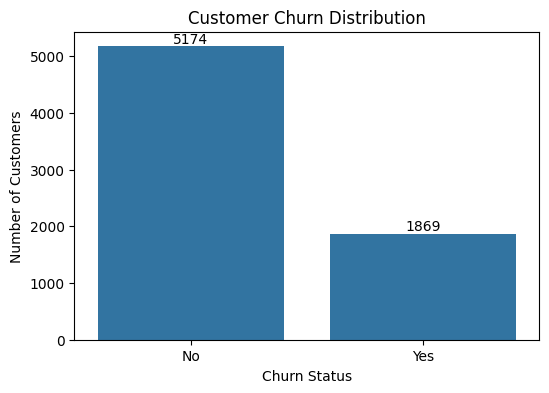

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [16]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

print((df["Churn"].value_counts(normalize=True) * 100).round(2))

### Insight: Overall Churn Distribution

- Out of 7,043 customers, 5,174 customers (73.46%) did not churn and 1,869 customers (26.54%) churned.
- Although most customers stayed, more than one-fourth of customers left the telecom service, which is a meaningful business retention problem.
- The target variable is moderately imbalanced, so later model evaluation will use recall, F1-score, and ROC-AUC along with accuracy.

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


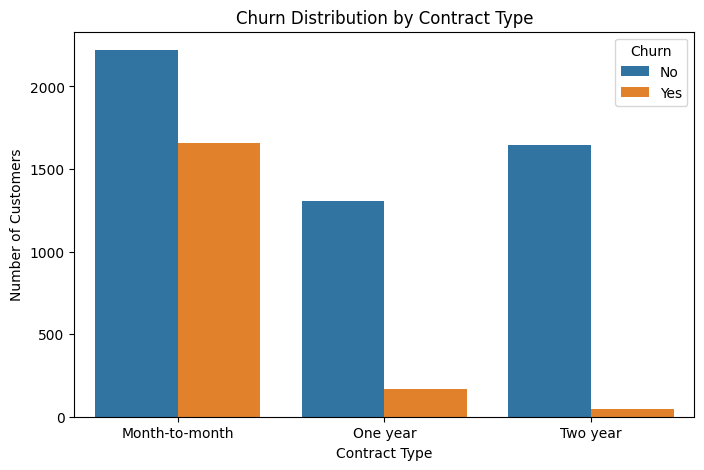

In [17]:
contract_churn_rate = (
    pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
).round(2)

display(contract_churn_rate)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

### Insight: Contract Type and Churn

- Customers with month-to-month contracts had the highest churn rate: **42.71%**.
- Customers with one-year contracts had a much lower churn rate of **11.27%**.
- Customers with two-year contracts had the lowest churn rate: **2.83%**.
- This suggests that longer-term contracts are strongly associated with customer retention.
- A practical retention strategy would be to target month-to-month customers with incentives to upgrade to annual or two-year plans.

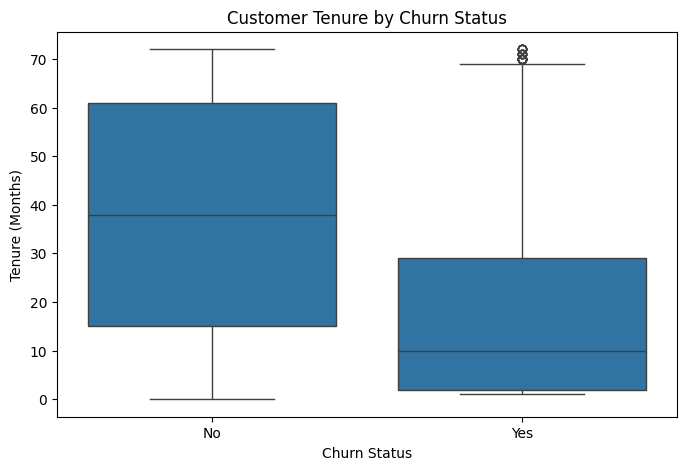

,count,mean,median,min,max
Churn,,,,,
No,5174,37.57,38.0,0,72
Yes,1869,17.98,10.0,1,72


In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")
plt.show()

tenure_summary = df.groupby("Churn")["tenure"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

display(tenure_summary)

### Insight: Customer Tenure and Churn

- Customers who did not churn had an average tenure of **37.57 months** and a median tenure of **38 months**.
- Customers who churned had a much lower average tenure of **17.98 months** and a median tenure of **10 months**.
- This indicates that churn is much more common among newer customers, especially during the early months of their relationship with the company.
- Retention efforts should focus on onboarding, early customer support, and targeted offers during the first year.

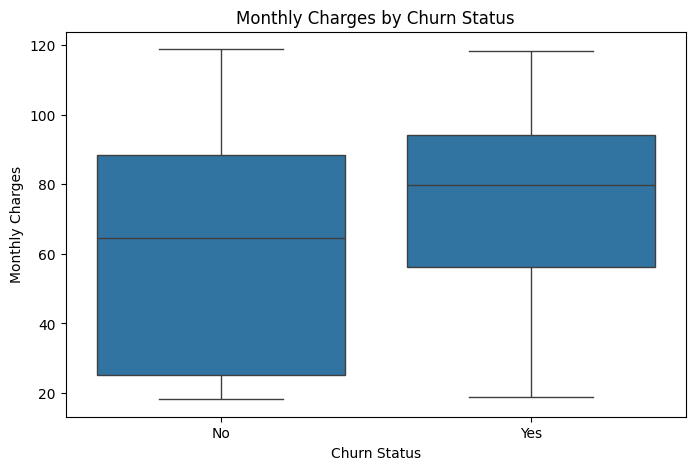

,count,mean,median,min,max
Churn,,,,,
No,5174,61.27,64.43,18.25,118.75
Yes,1869,74.44,79.65,18.85,118.35


In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.show()

monthly_charges_summary = df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

display(monthly_charges_summary)

### Insight: Monthly Charges and Churn

- Customers who churned had an average monthly charge of **74.44**, compared with **61.27** for customers who stayed.
- The median monthly charge was also higher for churned customers: **79.65** versus **64.43**.
- Higher monthly charges appear to be associated with greater churn risk.
- The company could investigate pricing, value perception, and plan benefits for higher-paying customers, then offer suitable discounts or plan alternatives.

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


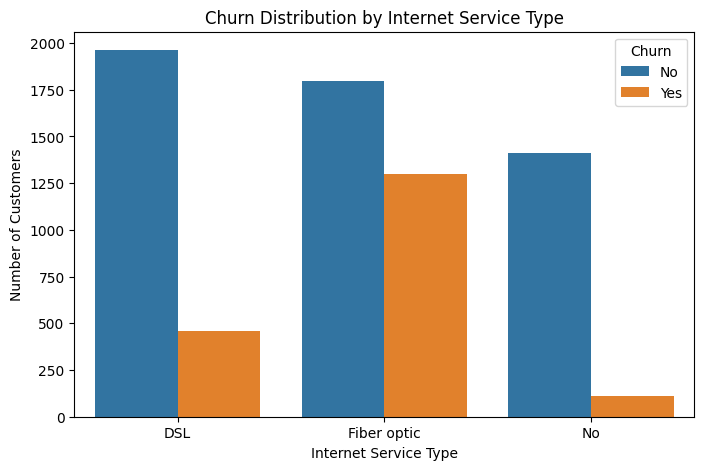

In [20]:
internet_churn_rate = (
    pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100
).round(2)

display(internet_churn_rate)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn Distribution by Internet Service Type")
plt.xlabel("Internet Service Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

### Insight: Internet Service Type and Churn

- Fiber optic customers had the highest churn rate at approximately **41.89%**.
- DSL customers had a lower churn rate of approximately **18.96%**.
- Customers with no internet service had the lowest churn rate at approximately **7.40%**.
- The high churn among fiber optic customers may indicate concerns related to pricing, service quality, competition, or customer expectations.
- The company should investigate the fiber optic customer experience and target this segment with retention offers or service-improvement initiatives.

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


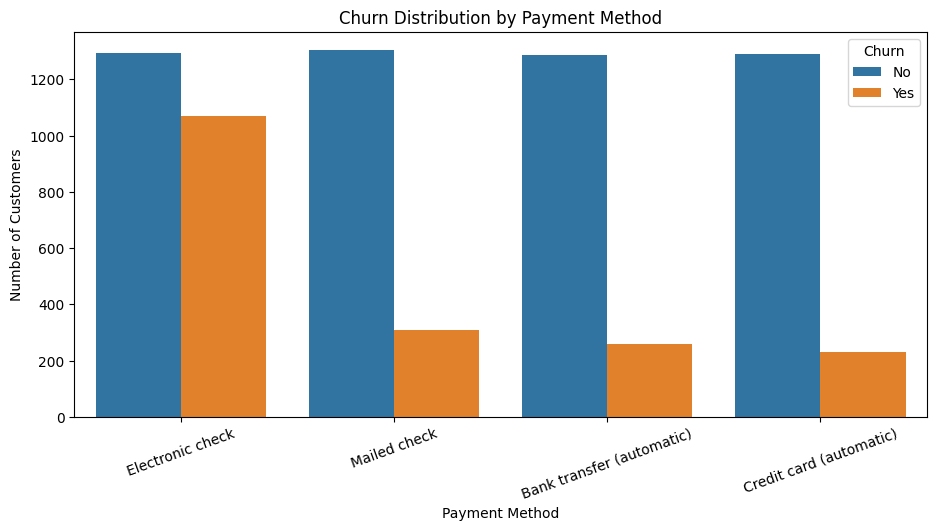

In [21]:
payment_churn_rate = (
    pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100
).round(2)

display(payment_churn_rate)

plt.figure(figsize=(11, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Churn Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.legend(title="Churn")
plt.show()

### Insight: Payment Method and Churn

- Customers using **electronic check** had the highest churn rate at **45.29%**.
- Customers using **mailed check** had a churn rate of **19.11%**.
- Customers using automatic payments had lower churn rates:
  - **Bank transfer (automatic): 16.71%**
  - **Credit card (automatic): 15.24%**
- This suggests that automatic payment methods are associated with better customer retention.
- The company could encourage electronic-check customers to switch to automatic payment options through simple setup support or incentives.

In [22]:
service_columns = [
    "OnlineSecurity",
    "TechSupport",
    "DeviceProtection",
    "OnlineBackup"
]

for column in service_columns:
    churn_rate = (
        pd.crosstab(df[column], df["Churn"], normalize="index") * 100
    ).round(2)

    print(f"\nChurn rate by {column}:")
    display(churn_rate)


Churn rate by OnlineSecurity:


Churn,No,Yes
OnlineSecurity,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61



Churn rate by TechSupport:


Churn,No,Yes
TechSupport,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17



Churn rate by DeviceProtection:


Churn,No,Yes
DeviceProtection,,
No,60.87,39.13
No internet service,92.60,7.40
Yes,77.50,22.50



Churn rate by OnlineBackup:


Churn,No,Yes
OnlineBackup,,
No,60.07,39.93
No internet service,92.60,7.40
Yes,78.47,21.53


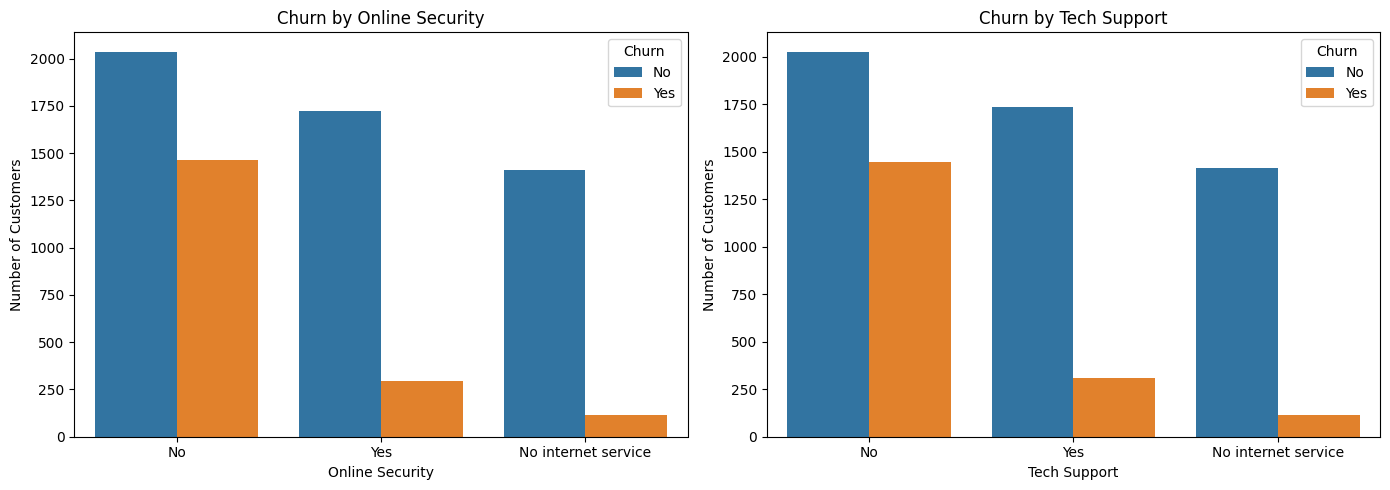

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn",
    ax=axes[0]
)
axes[0].set_title("Churn by Online Security")
axes[0].set_xlabel("Online Security")
axes[0].set_ylabel("Number of Customers")
axes[0].legend(title="Churn")

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn",
    ax=axes[1]
)
axes[1].set_title("Churn by Tech Support")
axes[1].set_xlabel("Tech Support")
axes[1].set_ylabel("Number of Customers")
axes[1].legend(title="Churn")

plt.tight_layout()
plt.show()

### Insight: Value-Added Services and Churn

- Customers without online security had a churn rate of **41.77%**, compared with **14.61%** for customers who had online security.
- Customers without tech support had a churn rate of **41.64%**, compared with **15.17%** for customers who had tech support.
- Online security and tech support are strongly associated with lower churn.
- The company can reduce churn by promoting these services through bundles, free trials, or targeted offers for high-risk customers.

### EDA Summary: Key Churn Drivers

The exploratory analysis identified several customer segments with higher churn risk:

- Month-to-month contract customers had the highest churn rate at 42.71%.
- Customers with shorter tenure were more likely to churn; churned customers had a median tenure of 10 months.
- Customers who churned had higher average monthly charges than customers who stayed.
- Fiber optic customers had a high churn rate of 41.89%.
- Electronic-check customers had the highest payment-method churn rate at 45.29%.
- Customers without online security or tech support had churn rates above 41%.

These findings suggest that the company should prioritize early-tenure customers, month-to-month customers, fiber optic users, electronic-check users, and customers without support-related services for retention campaigns.

## 6. Feature Engineering and Preprocessing

Machine-learning models require numerical input features. In this section, the target variable is encoded, the dataset is split into training and testing sets, and a reusable preprocessing pipeline is created for numerical and categorical features.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Create feature matrix X and target variable y
X = df.drop(columns="Churn")
y = df["Churn"].map({"No": 0, "Yes": 1})

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Feature matrix shape: (7043, 19)
Target variable shape: (7043,)

Target values:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [26]:
# Split data: 80% for training and 20% for testing.
# stratify=y preserves the same churn proportion in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training feature shape: (5634, 19)
Testing feature shape: (1409, 19)

Training target distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [27]:
# Separate feature columns by data type
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numerical features: 4
Number of categorical features: 15


### Preprocessing Plan

- Numerical features (`SeniorCitizen`, `tenure`, `MonthlyCharges`, and `TotalCharges`) will be standardized using `StandardScaler`.
- Categorical features will be converted into numeric columns using `OneHotEncoder`.
- Both transformations will be combined using `ColumnTransformer`.
- The preprocessing steps will be placed inside a pipeline so that the same transformations are applied consistently during training, testing, API prediction, and deployment.

In [29]:
# Create preprocessing steps for numerical and categorical features

# Standardize numerical columns so their scales are comparable
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

# Convert categorical text columns into numeric one-hot encoded columns
categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Apply the correct transformation to each group of columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [30]:
# Fit the preprocessor only on training data, then transform training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (5634, 45)
Processed testing data shape: (1409, 45)


### Preprocessing Validation

- The preprocessing pipeline was fitted only on the training data to prevent data leakage.
- The same fitted pipeline was used to transform the test data.
- The original 19 input features were converted into 45 numerical features after one-hot encoding categorical variables.
- The processed training data has 5,634 rows and 45 features, while the processed test data has 1,409 rows and 45 features.

## 7. Model Training and Evaluation

### 7.1 Logistic Regression Baseline

Logistic Regression is used as the baseline model because it is simple, fast, and interpretable. Its performance will be compared with Random Forest and XGBoost later.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Combine preprocessing and Logistic Regression into one reusable pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Train the complete pipeline on the training data
logistic_pipeline.fit(X_train, y_train)

# Make predictions on unseen test data
y_pred_lr = logistic_pipeline.predict(X_test)
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-score : {lr_f1:.4f}")
print(f"ROC-AUC  : {lr_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=["No Churn", "Churn"]))

Logistic Regression Results
-----------------------------------
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-score : 0.6040
ROC-AUC  : 0.8421

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



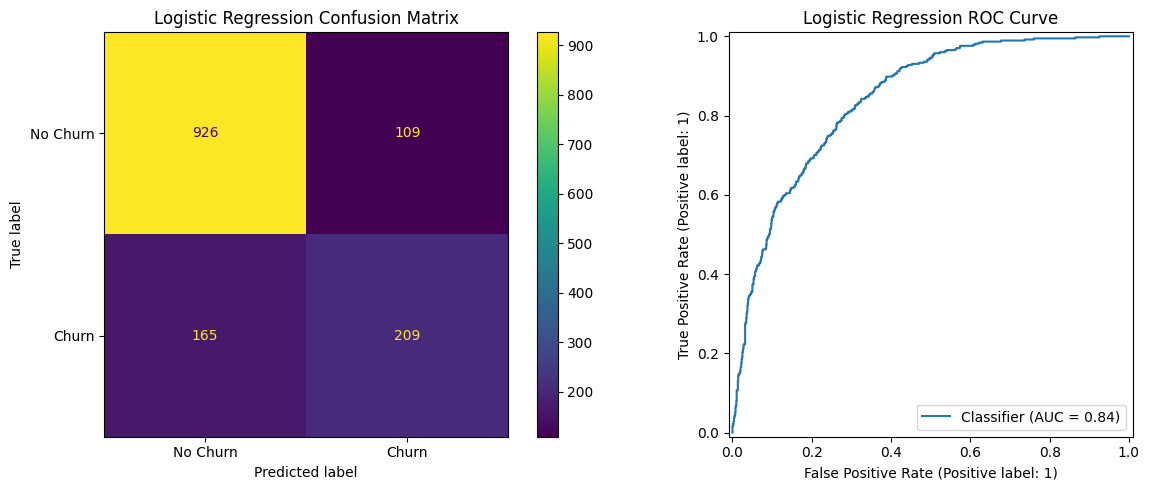

In [33]:
# Visual evaluation of Logistic Regression

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["No Churn", "Churn"],
    ax=axes[0]
)
axes[0].set_title("Logistic Regression Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    ax=axes[1]
)
axes[1].set_title("Logistic Regression ROC Curve")

plt.tight_layout()
plt.show()

### Logistic Regression Baseline Insight

- Logistic Regression achieved an ROC-AUC of **0.8421**, showing good ability to distinguish between churn and non-churn customers.
- The model achieved a churn recall of **55.88%**, meaning it identified about 56% of customers who actually churned.
- Recall can be improved later through model comparison and threshold tuning.
- This model will serve as the interpretable baseline for comparison with Random Forest and XGBoost.

### 7.2 Random Forest Classifier

Random Forest is an ensemble model that combines many decision trees. It can capture complex relationships between customer attributes and churn.

In [34]:
from sklearn.ensemble import RandomForestClassifier

# Combine preprocessing and Random Forest into one pipeline
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the pipeline
random_forest_pipeline.fit(X_train, y_train)

# Predictions on test data
y_pred_rf = random_forest_pipeline.predict(X_test)
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

# Evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1-score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["No Churn", "Churn"]))

Random Forest Results
-----------------------------------
Accuracy : 0.7835
Precision: 0.6211
Recall   : 0.4733
F1-score : 0.5372
ROC-AUC  : 0.8227

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86      1035
       Churn       0.62      0.47      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



### Random Forest Evaluation Insight

- Random Forest achieved an ROC-AUC of **0.8227**, which is lower than the Logistic Regression baseline.
- Its churn recall was **47.33%**, meaning it identified fewer actual churners than Logistic Regression.
- Although Random Forest can model nonlinear patterns, it did not outperform Logistic Regression on this dataset with the current configuration.
- The model is retained for comparison, but Logistic Regression is currently the stronger candidate.

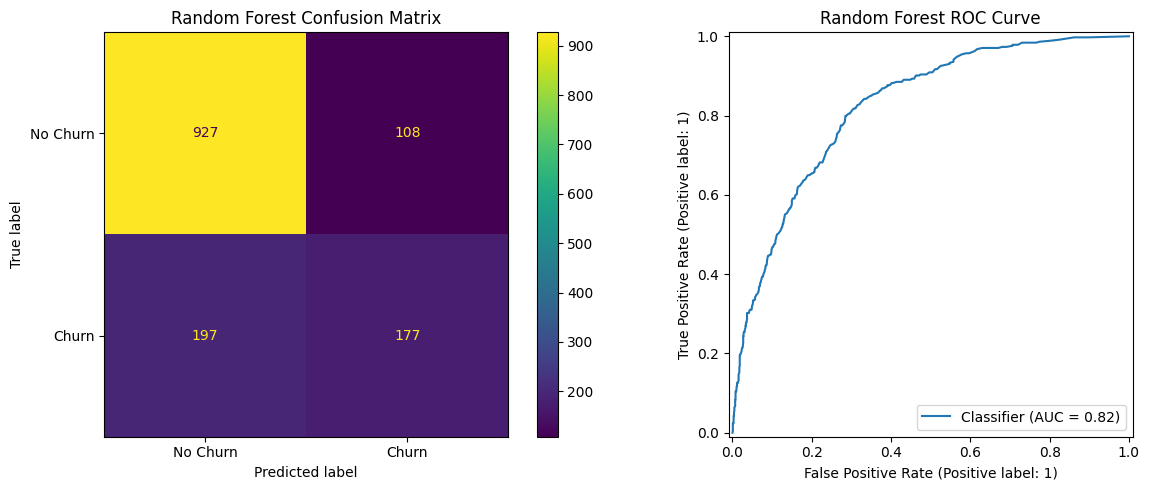

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No Churn", "Churn"],
    ax=axes[0]
)
axes[0].set_title("Random Forest Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    ax=axes[1]
)
axes[1].set_title("Random Forest ROC Curve")

plt.tight_layout()
plt.show()

In [36]:
from xgboost import XGBClassifier

# Combine preprocessing and XGBoost into one pipeline
xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the pipeline
xgboost_pipeline.fit(X_train, y_train)

# Predictions on test data
y_pred_xgb = xgboost_pipeline.predict(X_test)
y_prob_xgb = xgboost_pipeline.predict_proba(X_test)[:, 1]

# Evaluation metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("-" * 35)
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=["No Churn", "Churn"]))

XGBoost Results
-----------------------------------
Accuracy : 0.7970
Precision: 0.6438
Recall   : 0.5267
F1-score : 0.5794
ROC-AUC  : 0.8411

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87      1035
       Churn       0.64      0.53      0.58       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



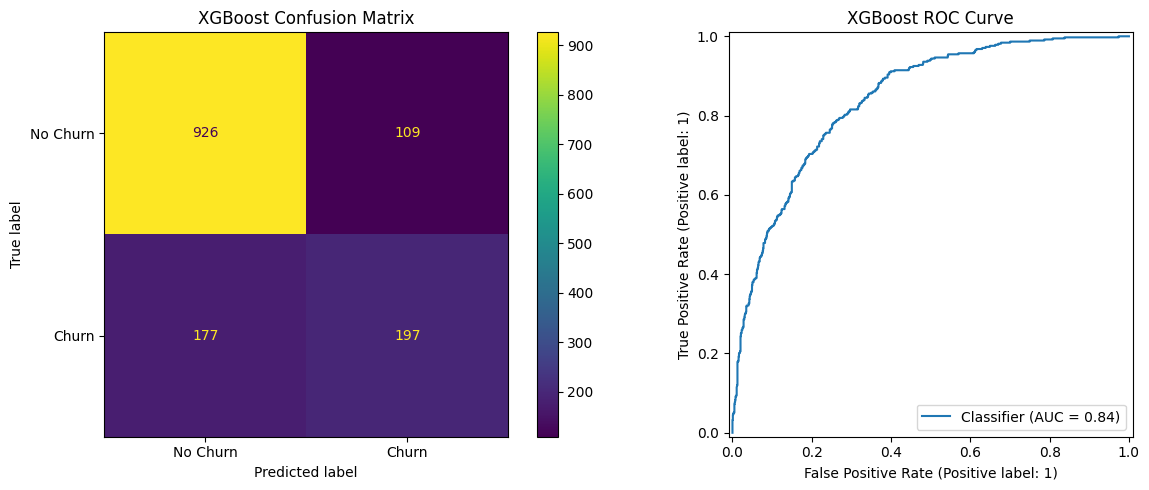

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_xgb,
    display_labels=["No Churn", "Churn"],
    ax=axes[0]
)
axes[0].set_title("XGBoost Confusion Matrix")

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    ax=axes[1]
)
axes[1].set_title("XGBoost ROC Curve")

plt.tight_layout()
plt.show()

## 8. Model Evaluation and Selection

The three models are compared using accuracy, precision, recall, F1-score, and ROC-AUC. Since churn prediction is a business-retention problem, recall, F1-score, and ROC-AUC are especially important.

In [38]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],
    "F1-score": [
        lr_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        lr_roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

model_comparison = model_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8421
1,XGBoost,0.7970,0.6438,0.5267,0.5794,0.8411
2,Random Forest,0.7835,0.6211,0.4733,0.5372,0.8227


<Figure size 800x600 with 0 Axes>

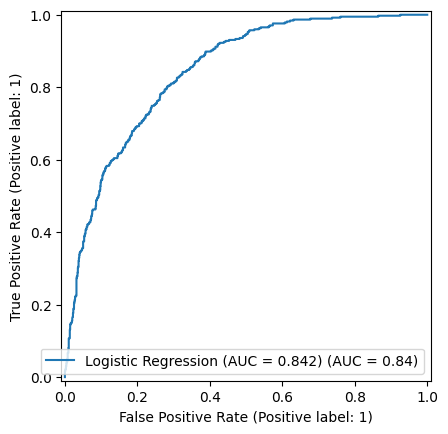

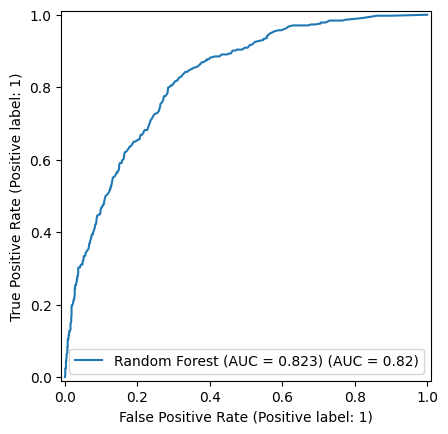

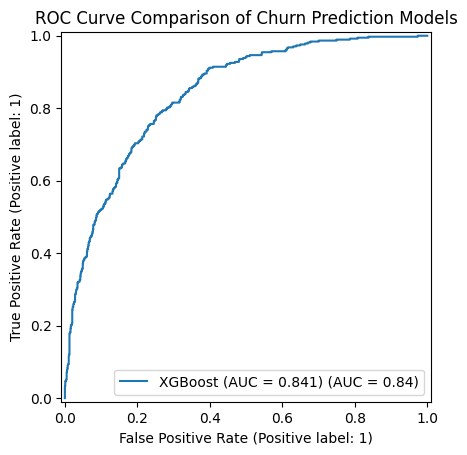

In [39]:
plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name=f"Logistic Regression (AUC = {lr_roc_auc:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name=f"Random Forest (AUC = {rf_roc_auc:.3f})"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name=f"XGBoost (AUC = {xgb_roc_auc:.3f})"
)

plt.title("ROC Curve Comparison of Churn Prediction Models")
plt.show()

### Final Model Selection

Logistic Regression was selected as the final model because it achieved the highest ROC-AUC (**0.8421**), accuracy (**0.8055**), precision (**0.6572**), recall (**0.5588**), and F1-score (**0.6040**) among the evaluated models.

Although XGBoost achieved a very similar ROC-AUC score, Logistic Regression performed better across the other key metrics and is easier to interpret, faster to deploy, and more suitable for this dataset.

Random Forest performed lower than both Logistic Regression and XGBoost, particularly on churn recall and F1-score.

Therefore, Logistic Regression was selected as the final baseline model for threshold tuning, explainability, and deployment.

### 8.1 Threshold Tuning for Churn Recall

The default classification threshold is 0.50. Since the business goal is to identify customers at risk of churn, different thresholds are evaluated to balance recall and precision.

In [40]:
threshold_results = []

for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55]:
    y_pred_threshold = (y_prob_lr >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-score": f1_score(y_test, y_pred_threshold),
        "Accuracy": accuracy_score(y_test, y_pred_threshold)
    })

threshold_comparison = pd.DataFrame(threshold_results)

display(threshold_comparison.round(4))

,Threshold,Precision,Recall,F1-score,Accuracy
0,0.30,0.5193,0.7540,0.6150,0.7495
1,0.35,0.5432,0.7059,0.6140,0.7644
2,0.40,0.5682,0.6684,0.6143,0.7771
3,0.45,0.6021,0.6150,0.6085,0.7899
4,0.50,0.6572,0.5588,0.6040,0.8055
5,0.55,0.6784,0.4626,0.5501,0.7991


### Threshold Selection Decision

- At the default threshold of 0.50, Logistic Regression achieved the highest accuracy (80.55%), but churn recall was only 55.88%.
- A threshold of 0.40 increased churn recall to 66.84%, meaning the model identified more customers who were likely to leave.
- The F1-score at 0.40 was 0.6143, which was slightly higher than the default-threshold F1-score of 0.6040.
- Although precision decreased to 56.82%, the threshold of 0.40 provides a better balance for a customer-retention use case.
- Therefore, 0.40 was selected as the operational churn-risk threshold for deployment.

In [41]:
# Final predictions using the selected business threshold
selected_threshold = 0.40

y_pred_final = (y_prob_lr >= selected_threshold).astype(int)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)

print("Final Logistic Regression Results at Threshold 0.40")
print("-" * 48)
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-score : {final_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=["No Churn", "Churn"]))

Final Logistic Regression Results at Threshold 0.40
------------------------------------------------
Accuracy : 0.7771
Precision: 0.5682
Recall   : 0.6684
F1-score : 0.6143

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.87      0.82      0.84      1035
       Churn       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



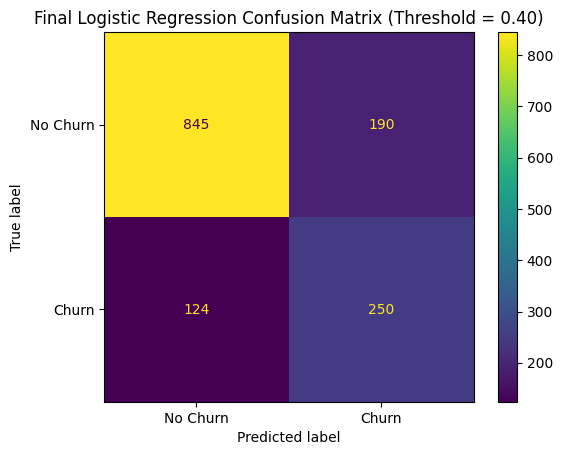

In [42]:
# Confusion matrix using the selected operational threshold
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_final,
    display_labels=["No Churn", "Churn"]
)

plt.title("Final Logistic Regression Confusion Matrix (Threshold = 0.40)")
plt.show()

### Final Model Performance

The deployed Logistic Regression model uses a churn-risk threshold of **0.40**.

- Accuracy: **77.71%**
- Precision: **56.82%**
- Recall: **66.84%**
- F1-score: **61.43%**

The model is designed to prioritize churn recall. It identifies approximately 67 out of every 100 customers who actually churn, allowing the company to target more at-risk customers with retention actions.

## 9. Churn-Driver Analysis

Logistic Regression coefficients are used to identify features that increase or decrease the predicted probability of churn. Positive coefficients increase churn risk, while negative coefficients are associated with lower churn risk.

In [43]:
# Get feature names created after preprocessing
feature_names = logistic_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Get coefficients from the trained Logistic Regression model
coefficients = logistic_pipeline.named_steps["model"].coef_[0]

# Create a feature-importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort from strongest churn-increasing feature to strongest churn-reducing feature
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).reset_index(drop=True)

print("Top 10 features associated with higher churn risk:")
display(feature_importance.head(10))

print("\nTop 10 features associated with lower churn risk:")
display(feature_importance.tail(10).sort_values(by="Coefficient"))

Top 10 features associated with higher churn risk:


,Feature,Coefficient
0,cat__InternetService_Fiber optic,0.634195
1,cat__Contract_Month-to-month,0.582883
2,num__TotalCharges,0.536253
3,cat__StreamingMovies_Yes,0.200938
4,cat__StreamingTV_Yes,0.200481
5,cat__PaymentMethod_Electronic check,0.197867
6,cat__OnlineSecurity_No,0.156279
7,cat__TechSupport_No,0.131503
8,cat__MultipleLines_Yes,0.104649
9,num__SeniorCitizen,0.053449



Top 10 features associated with lower churn risk:


,Feature,Coefficient
44,num__tenure,-1.257539
43,cat__Contract_Two year,-0.776594
42,cat__InternetService_DSL,-0.648646
41,num__MonthlyCharges,-0.591863
40,cat__PaperlessBilling_No,-0.343227
37,cat__StreamingTV_No internet service,-0.300104
38,cat__DeviceProtection_No internet service,-0.300104
35,cat__OnlineSecurity_No internet service,-0.300104
39,cat__OnlineBackup_No internet service,-0.300104
36,cat__InternetService_No,-0.300104


### Churn-Driver Findings from Logistic Regression

The coefficient analysis identified the following important churn drivers:

#### Features associated with higher churn risk

- **Fiber optic internet service** was the strongest churn-increasing feature.
- **Month-to-month contracts** were strongly associated with higher churn risk.
- Higher **TotalCharges** increased churn risk.
- Customers using **electronic check** had higher churn risk.
- Customers without **Online Security** or **Tech Support** had higher churn risk.
- Customers using streaming TV or streaming movies also showed a positive association with churn.

#### Features associated with lower churn risk

- **Longer customer tenure** was the strongest churn-reducing feature.
- **Two-year contracts** were strongly associated with lower churn risk.
- **DSL internet service** was associated with lower churn risk.
- Lower monthly charges were associated with lower churn risk.
- Customers without paperless billing showed lower churn risk.

These results support the EDA findings and suggest that retention campaigns should focus on newer customers, month-to-month customers, fiber optic users, electronic-check users, and customers without online security or tech support.

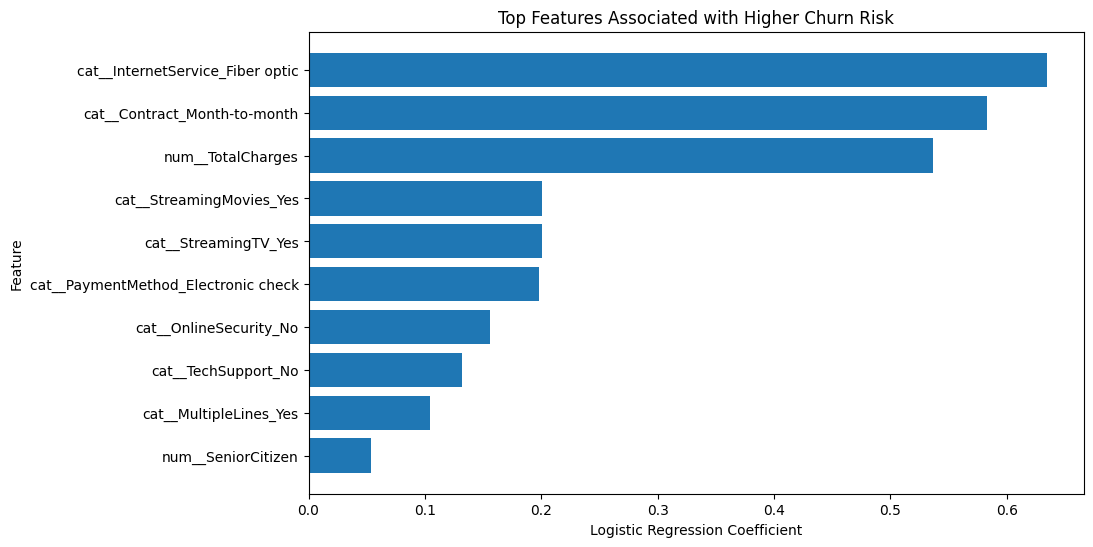

In [44]:
# Plot the 10 strongest churn-increasing features
top_risk_features = feature_importance.head(10).sort_values(
    by="Coefficient",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_risk_features["Feature"],
    top_risk_features["Coefficient"]
)

plt.title("Top Features Associated with Higher Churn Risk")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.show()

## 10. Save Final Model

The complete Logistic Regression pipeline is saved using Joblib. The saved pipeline includes preprocessing and the trained model, allowing the same transformations to be applied during API prediction and deployment.

In [45]:
import os
import joblib

# Create the models folder if it does not already exist
os.makedirs("../models", exist_ok=True)

# Save the complete trained pipeline
model_path = "../models/best_churn_model.pkl"
joblib.dump(logistic_pipeline, model_path)

# Save the selected operational threshold separately
threshold_path = "../models/model_threshold.txt"

with open(threshold_path, "w") as file:
    file.write(str(selected_threshold))

print(f"Model saved successfully at: {model_path}")
print(f"Threshold saved successfully at: {threshold_path}")

Model saved successfully at: ../models/best_churn_model.pkl
Threshold saved successfully at: ../models/model_threshold.txt


In [46]:
# Verify that the saved model can be loaded and used
loaded_model = joblib.load("../models/best_churn_model.pkl")

sample_prediction_probability = loaded_model.predict_proba(X_test.iloc[:1])[:, 1][0]
sample_prediction = "Churn" if sample_prediction_probability >= selected_threshold else "No Churn"

print("Sample churn probability:", round(sample_prediction_probability, 4))
print("Sample prediction:", sample_prediction)

Sample churn probability: 0.0459
Sample prediction: No Churn
